In [32]:
%reload_ext autoreload
%autoreload 2


import multiprocessing
import sys
import random

import matplotlib.pyplot as plt
import mplscience
import networkx as nx
import numba   
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import scipy
from scipy.spatial import distance
from scipy.cluster import hierarchy
import seaborn as sns
import squidpy as sq
import tqdm


SPATIAL_PACKAGE="/path/to/spatial/package"
DATA_DIR="/path/to/kpspatial/data/"
sys.path.append(SPATIAL_PACKAGE)

from utilities import target_site_utilities, spatial_utilities, colors

from IPython.display import Image
pd.set_option('display.max_columns', None)


## Figure 2e

In [34]:

to_merge = []
SAMPLES = ['M18_01', 'M18_02', 'M18_04', 'Curio_001',
           'C44_06', 'C44_08',
           'M11_06', 'M18_06', 'Curio_002',
           'M11_08', 'M18_17', 'Curio_003',
           'M11_14', 'M18_13', 'Curio_004',
           'M09_11', 'M09_13', 'M09_14',
           'M09_17', 'M09_18', 'M11_05',
           'Curio_09', 'Curio_10', 'C36_09',
           'C36_10', 'C36_11', 'C27_11',
           'M09_01', 'M09_04', 'M09_07', 'M09_08',
            'B94_04', 'B94_20', 'B95_24',
            'B99_22', 'C12_01', 'C12_02', 'C12_03',
            'C12_04', 'C12_05', 'C12_09', 'C12_10', 'C12_12'
]

for puck in SAMPLES:

    modules = pd.read_csv(f"{DATA_DIR}/slideseq//hotspot/{puck}_modules.tsv", sep='\t', index_col=0)
    modules = modules[~modules['Module'].isna()].sort_values(by='C', ascending=False)
    modules['Module'] = modules.apply(lambda x: f'{puck}.{int(x.Module)}', axis=1)

    to_merge.append(modules)

all_modules = pd.concat(to_merge)

jaccard_indices = pd.DataFrame(index=all_modules['Module'].unique(), columns=all_modules['Module'].unique())
all_module_genes = []
modules = list(all_modules['Module'].unique())
for module1 in tqdm.tqdm(modules):
    genes1 = all_modules[all_modules['Module'] == module1].index.values

    for module2 in modules:

        genes2 = all_modules[all_modules['Module'] == module2].index.values
        jaccard = len(np.intersect1d(genes1, genes2)) / len(np.union1d(genes1, genes2))
        jaccard_indices.loc[module1, module2] = jaccard


# remove modules that don't share significant overlap with more than 1 module
kii = jaccard_indices.apply(lambda x: np.sum(x > 0.2) > 1, axis=1)
print(f'Removing {len(jaccard_indices) - len(kii)} programs.')
jaccard_indices = jaccard_indices.loc[kii, kii]

mu = jaccard_indices.values.ravel().mean()
std = jaccard_indices.values.ravel().std()

jaccard_indices_normalized = (jaccard_indices - mu) / std

In [5]:
sample_metadata = pd.read_csv(f"{SPATIAL_PACKAGE}/data/puck_meta.txt", sep='\t', index_col=0)
sample_metadata.head(5)

,ID,Mouse,Area,Batch,Slide-seq ID,mESC
Puck,,,,,,
B94_04,S-seq 1,M-1,Primary,1,1,m2E1
B94_20,S-seq 2,M-2,Primary,1,2,m2E1
B94_23,S-seq 3,M-3,Primary,1,3,m2E1
B95_24,S-seq 4,M-4,Primary,1,4,m2E1
B99_22,S-seq 5,M-5,Primary,1,5,m2E1


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


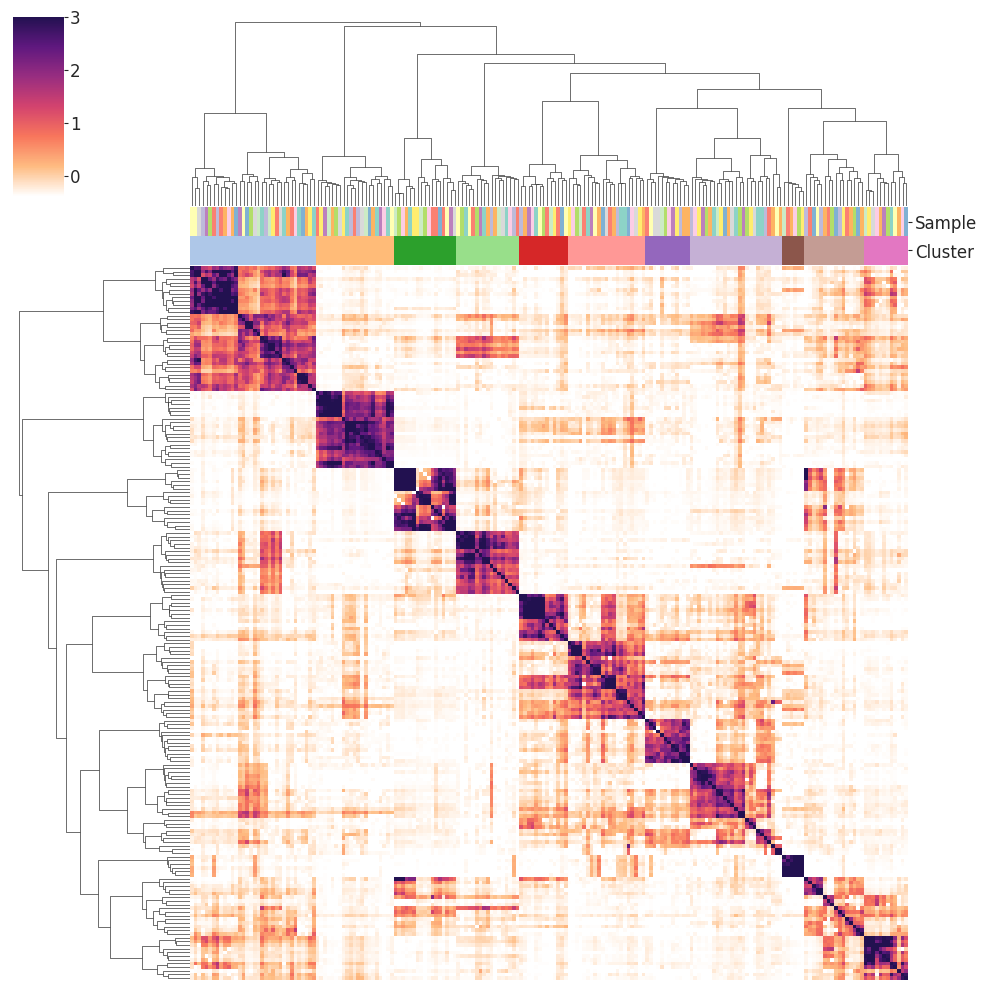

In [23]:
sns.set_style("whitegrid", {'axes.grid' : False})

module_hierarchy = hierarchy.linkage(
    distance.pdist(jaccard_indices_normalized.astype(float), metric='euclidean'),
    method='ward'
)
hierarchical_clusters = hierarchy.fcluster(module_hierarchy, t=12, criterion="maxclust")

posthoc_merge = {2: 1}
module_to_cluster = {}
for i, module in zip(range(len(jaccard_indices_normalized.index)), jaccard_indices_normalized.index):
    assignment = hierarchical_clusters[i]
    if hierarchical_clusters[i] in posthoc_merge:
        assignment = posthoc_merge[hierarchical_clusters[i]]
    module_to_cluster[module] = assignment

palette = sns.color_palette("tab20").as_hex()
_colors = pd.DataFrame.from_dict({module: palette[module_to_cluster[module]] for module in jaccard_indices_normalized.index}, orient='index', columns = ['Cluster'])

palette2 = sns.color_palette('Set3').as_hex()
samples = np.unique([val.split(".")[0] for val in _colors.index.values])
sample_to_index = dict(zip(samples, range(len(samples))))
_colors['Sample'] = [palette2[ np.mod(sample_to_index[val.split(".")[0]], len(palette2)) ] for val in _colors.index.values]

with mplscience.style_context():
    
    sns.clustermap(jaccard_indices_normalized.astype(float),
                   z_score=None,
                   cmap=sns.color_palette("blend:#FFFFFF,#febb81,#f8765c,#d3436e,#982d80,#5f187f,#221150",as_cmap=True),
                   vmax=3,
                   metric='euclidean',
                   method='ward',
                   col_linkage=module_hierarchy,
                   row_cluster=True,
                   col_colors=_colors[['Sample', 'Cluster']],
                   annot_kws={'font-size': 3},
                   xticklabels=False,
                   yticklabels=False,
                )

    plt.show()

In [8]:
# load in community scores
community_module_summary = pd.read_csv(f'{DATA_DIR}/slideseq/hotspot/hotspot_modules_consensus.scores.tsv', sep='\t', index_col = 0)
community_module_summary.index = community_module_summary.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)

community_module_genes = pd.read_csv(f'./data/hotspot_modules_consensus.tsv', sep='\t', index_col = 0)

In [9]:
community_module_summary.head(5)

,Joint_Module_6,Joint_Module_2,Joint_Module_3,Joint_Module_5,Joint_Module_1,Joint_Module_11,Joint_Module_4,Joint_Module_7,Joint_Module_8,Joint_Module_10,Joint_Module_9,Sample
M18_01.AAAAATNAAACCAG,0.024362,0.076691,0.106999,0.168335,-0.152229,-0.054039,0.220815,-0.038360,-0.076549,0.107414,-0.082653,M18_01
M18_01.AAANACAAAATAGA,0.110122,-0.003375,-0.078438,-0.008844,0.021297,0.051976,-0.162382,0.182293,0.014471,0.129887,-0.068416,M18_01
M18_01.AAAAANTAAATTGA,-0.105580,-0.033142,-0.051942,-0.097325,-0.040726,-0.077401,0.059919,0.006306,-0.036873,-0.034693,-0.072624,M18_01
M18_01.AAANACAATAACAG,-0.129291,-0.058670,-0.024205,-0.153559,0.188195,-0.019283,-0.104308,-0.173507,-0.058034,0.101211,-0.109423,M18_01
M18_01.AAATANACTTTTCT,0.039271,0.206507,0.021547,-0.080201,-0.083716,0.033781,-0.040289,0.179095,0.064162,-0.005607,0.064683,M18_01


In [3]:
community_module_genes

,C,Z,Pval,FDR,Module,Community_Module
Gene,,,,,,
Ighm,0.431007,315.110194,0.000000,0.000000,M18_01.6,Joint_Module_6
Igkc,0.420375,307.761249,0.000000,0.000000,M18_01.6,Joint_Module_6
Jchain,0.398641,291.612481,0.000000,0.000000,M18_01.6,Joint_Module_6
Ighg2c,0.381576,278.948775,0.000000,0.000000,M18_01.6,Joint_Module_6
Reg3g,0.381079,275.529333,0.000000,0.000000,M18_01.2,Joint_Module_2
...,...,...,...,...,...,...
Sftpb,0.008764,3.011440,0.001300,0.084844,C12_12.2,Joint_Module_1
Soat1,0.008745,2.955376,0.001561,0.097660,C12_12.2,Joint_Module_1
Vmp1,0.008707,2.951999,0.001579,0.098424,C12_12.2,Joint_Module_1


In [26]:
def get_genes_in_community(joint_module):

    joint_module['Gene'] = joint_module.index.values
    unique_modules = joint_module['Module'].unique()

    genes = joint_module['Gene'].value_counts()
    module_genes = genes[genes > int(0.25 * len(unique_modules))]

    return module_genes

community_10 = get_genes_in_community(community_module_genes[community_module_genes['Community_Module'] == 'Joint_Module_10'])
community_3 = get_genes_in_community(community_module_genes[community_module_genes['Community_Module'] == 'Joint_Module_3'])

jaccard_overlap = len(np.intersect1d(community_10.index.values, community_3.index.values)) / len(np.union1d(community_10.index.values, community_3.index.values))

print(len(community_10.index.values), len(community_3.index.values), len(np.intersect1d(community_3.index.values, community_10.index.values)), jaccard_overlap)

non_overlapping_10 = np.setdiff1d(community_10.index.values, community_3.index.values)
non_overlapping_3 = np.setdiff1d(community_3.index.values, community_10.index.values)

program_names = [mod for mod in community_module_genes['Community_Module'].unique() if type(mod) == str]

program_to_genes = {}
for program_name, group in community_module_genes.groupby('Community_Module'):

    if type(program_name) != str:
        continue
    
    genes = get_genes_in_community(group).index.values
    program_to_genes[program_name] = genes

# get unique genes
program_to_genes_unique = {}
to_merge = []
for program_name in program_to_genes.keys():

    _list = [list(program_to_genes[x]) for x in program_to_genes.keys() if x != program_name]
    other_genes = [_item for sublist in _list for _item in sublist]
    uniq_genes = np.setdiff1d(program_to_genes[program_name], other_genes)
    program_to_genes_unique[program_name] = uniq_genes

    new_df = pd.DataFrame([uniq_genes, [program_name]*len(uniq_genes)]).T
    to_merge.append(new_df)
    
hotspot_modules_uniq = pd.concat(to_merge)
hotspot_modules_uniq.columns = ['gene', 'Community_Module']
# hotspot_modules_uniq.to_csv("./data/hotspot_modules_consensus_uniq.tsv", sep='\t')

/tmp/ipykernel_53308/116704207.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joint_module['Gene'] = joint_module.index.values
/tmp/ipykernel_53308/116704207.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joint_module['Gene'] = joint_module.index.values


156 1565 78 0.04747413268411443


### Extended Data Figure 5b

In [ ]:
## Score gene sets in sample

sample_name="Curio_003"
adata_raw = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{sample_name}_adata.h5ad')
adata_raw.obs_names = [f'{sample_name}.{x}' for x in adata_raw.obs_names]

program_names = [col for col in community_module_summary if 'Module' in col]
adata_raw.obs[program_names] = community_module_summary.loc[adata_raw.obs_names, program_names]

/tmp/ipykernel_53308/1390474477.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_raw, color=program, frameon=False, vmin='p3', vmax='p97', spot_size=30, cmap='viridis', show=False, ax=ax)


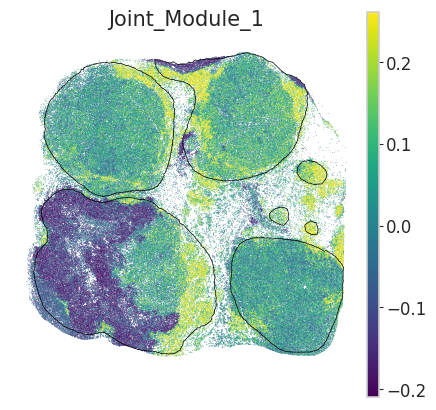

/tmp/ipykernel_53308/1390474477.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_raw, color=program, frameon=False, vmin='p3', vmax='p97', spot_size=30, cmap='viridis', show=False, ax=ax)


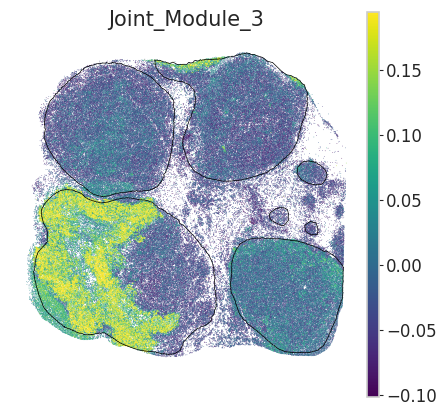

/tmp/ipykernel_53308/1390474477.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_raw, color=program, frameon=False, vmin='p3', vmax='p97', spot_size=30, cmap='viridis', show=False, ax=ax)


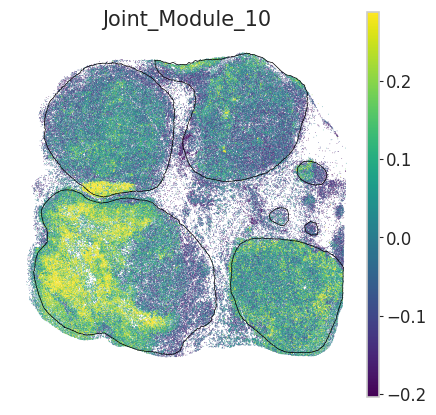

In [13]:
# just show a few as an example

for program in ['Joint_Module_1', 'Joint_Module_3', 'Joint_Module_10']:

    with mplscience.style_context():
        h = plt.figure(figsize=(5,5))
        ax = plt.gca()
        sc.pl.spatial(adata_raw, color=program, frameon=False, vmin='p3', vmax='p97', spot_size=30, cmap='viridis', show=False, ax=ax)

        for tumor_id in adata_raw.obs['tumor_id'].unique():
            if tumor_id != 'non-tumor':
                spatial_utilities.plot_boundary(adata_raw, ax=ax, tumor_id=tumor_id, max_distance=1e6, width=0.5) 
        plt.show()

/tmp/ipykernel_53308/2065645571.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_raw, color='program_assignments', frameon=False, groups=['Joint_Module_3', 'Joint_Module_10', 'Joint_Module_5', 'Joint_Module_7',


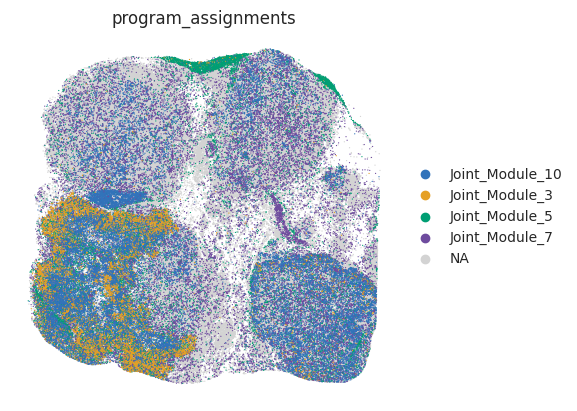

In [35]:
color_map = colors.MODULE_COLORS
color_map = {f'Joint_Module_{i}': color_map[i] for i in color_map.keys()}

assignments = np.array(program_names)[adata_raw.obs[program_names].apply(lambda x: np.argmax(x), axis=1)]
adata_raw.obs['program_assignments'] = assignments
adata_raw.obs['program_assignments'] = adata_raw.obs['program_assignments'].astype('category')
adata_raw.uns['program_assignments_colors'] = [color_map[mod] for mod in adata_raw.obs['program_assignments'].cat.categories]

sc.pl.spatial(adata_raw, color='program_assignments', frameon=False, groups=['Joint_Module_3', 'Joint_Module_10', 'Joint_Module_5', 'Joint_Module_7',
                                                                             ], spot_size=50, cmap='viridis', show=False)
plt.show()


### Assign community abundances

In [14]:
to_merge = []

SAMPLES = ['M18_01', 'M18_02', 'M18_04', 'Curio_001',
           'C44_06', 'C44_08', 'M11_06', 'M18_06', 'Curio_002',
           'M11_08', 'M18_17', 'Curio_003',
           'M11_14', 'M18_13', 'Curio_004',
           'M09_11', 'M09_13', 'M09_14',
           'M09_17', 'M09_18', 'M11_05',
           'Curio_09', 'Curio_10', 'C36_09', 'C36_10', 'C36_11', 'C27_11',
           'M09_01', 'M09_04', 'M09_07', 'M09_08',
            'B94_04', 'B94_20', 'B94_20', 'B95_24',
            'B99_22', 'C12_01', 'C12_02', 'C12_03',
            'C12_04', 'C12_05', 'C12_09', 'C12_10', 'C12_12'
]

community_module_summary = pd.read_csv(f'{DATA_DIR}/slideseq/hotspot/hotspot_modules_consensus.scores.tsv', sep='\t', index_col = 0)
community_module_summary.index = community_module_summary.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)
community_module_summary['tumor'] = 'non-tumor'

fitness_signature = pd.read_csv(f"{DATA_DIR}/slideseq/fitness_signature.tsv", sep=' ', index_col = 0)
fitness_signature.index = fitness_signature.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)
fitness_signature['tumor'] = 'non-tumor'

# add tumor information
for sample_name in tqdm.tqdm(SAMPLES):
    if sample_name == 'B95_24':
        continue
        
    segmented_adata = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{sample_name}_adata.h5ad')
    segmented_adata.obs_names = [f'{sample_name}.{x}' for x in segmented_adata.obs_names]

    overlapping = np.intersect1d(community_module_summary.index, segmented_adata.obs_names)
    community_module_summary.loc[overlapping, 'tumor'] = segmented_adata.obs.loc[overlapping, 'tumor_id']

    overlapping = np.intersect1d(fitness_signature.index, segmented_adata.obs_names)
    fitness_signature.loc[overlapping, 'tumor'] = segmented_adata.obs.loc[overlapping, 'tumor_id']

  0%|          | 0/44 [00:00<?, ?it/s]/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  2%|▏         | 1/44 [00:06<04:39,  6.51s/it]/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  5%|▍         | 2/44 [00:11<04:01,  5.76s/it]/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
  7%|▋         | 3/44 [00:16<03:46,  5.52s/it]/orcd/data/ki/001/lab/jones/mgjones/minicond

In [18]:
to_merge = []
for sample_name, module_df in tqdm.tqdm(community_module_summary.groupby(['Sample', 'tumor'])):

    # sample_name = (sample_name, "all")
    if sample_name[1] == 'non-tumor':
        continue
        
    module_df = module_df[[col for col in module_df.columns if 'Joint' in col]]
    assignments = pd.DataFrame(np.array(module_df.columns)[module_df.apply(lambda x: np.argmax(x), axis=1)], columns=['program_assignments'])

    fracs = assignments.value_counts() / len(assignments)
    fracs = fracs.reset_index()
    fracs['Sample'] = f'{sample_name[0]}-{sample_name[1]}'
    to_merge.append(fracs)

community_fractions = pd.concat(to_merge)

piv = pd.pivot(community_fractions, index='Sample', columns=['program_assignments'], values='count')

100%|██████████| 163/163 [00:14<00:00, 11.33it/s]


### Extended Data Figure 5c

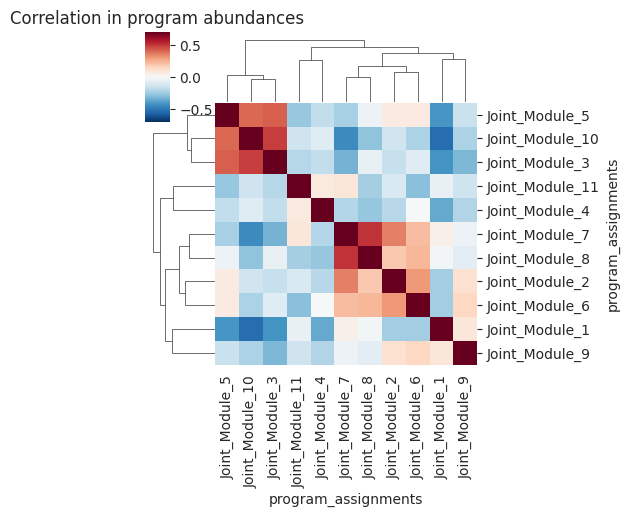

In [19]:
sns.clustermap(piv.corr(), cmap='RdBu_r', vmin=-0.7, vmax=0.7, figsize=(5,5))
plt.title("Correlation in program abundances")
plt.show()

### Community assignments in de-duplicated communities (Extended Data Fig 5d)

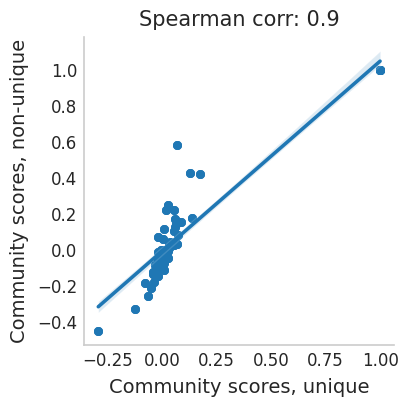

In [21]:
community_module_summary_uniq = pd.read_csv(f'{DATA_DIR}/slideseq/hotspot/hotspot_modules_consensus_uniq.scores.tsv', sep='\t', index_col = 0)
community_module_summary_uniq.index = community_module_summary_uniq.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)

module_names = [col for col in module_df.columns if 'Joint' in col]

uniq_corrs = community_module_summary_uniq[module_names].corr()
non_uniq_corrs = community_module_summary[module_names].corr()

with mplscience.style_context():


    corr = scipy.stats.spearmanr(uniq_corrs.values.ravel(), non_uniq_corrs.values.ravel())[0]
    sns.scatterplot(x=uniq_corrs.values.ravel(), y=non_uniq_corrs.values.ravel(), edgecolor=None)
    sns.regplot(x=uniq_corrs.values.ravel(), y=non_uniq_corrs.values.ravel(), scatter=False)
    plt.xlabel("Community scores, unique")
    plt.ylabel("Community scores, non-unique")
    plt.title(f'Spearman corr: {round(corr, 2)}')
    plt.show()

### Extended Data Figure 5a

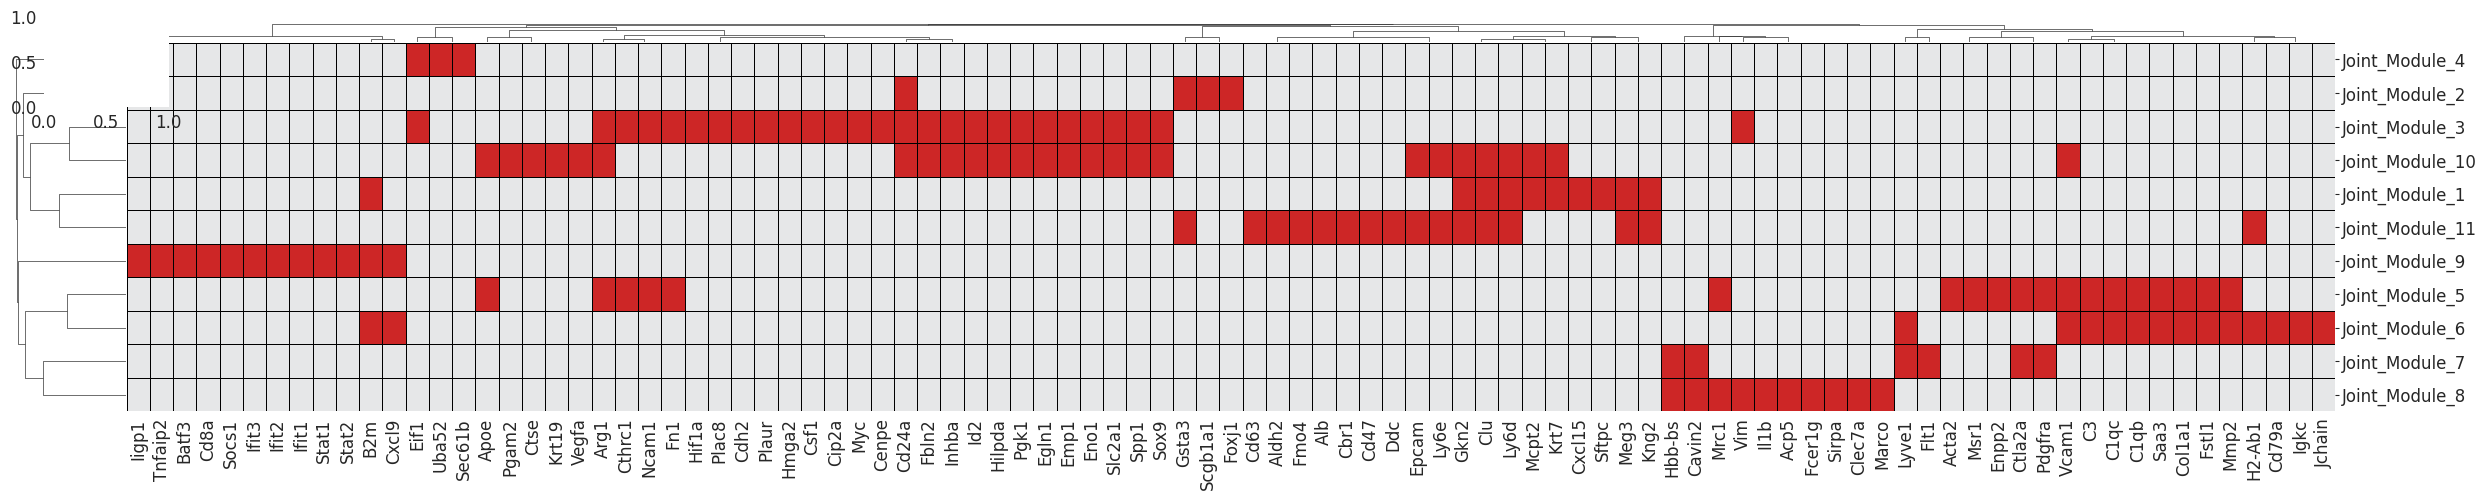

In [30]:
genes = ['Cxcl15', 'Sftpc',
         'Scgb1a1', 'Foxj1',
         'Spp1', 'Arg1', 'Vim', 'Myc', 'Cenpe', 'Cip2a', 'Csf1', 'Hmga2', 'Ncam1', 'Plaur', 'Cdh2',
         'Uba52', 'Eif1', 'Sec61b',
         'Fstl1', 'Mmp2', 'Col1a1', 'Saa3', 'Vcam1', 'C1qb', 'C1qc', 'Fn1', 'Msr1', 'Enpp2', 'Acta2', 'Cthrc1',
         'Igkc', 'Jchain', 'Cd79a', 'C3', 'Lyve1', 'B2m', 'H2-Ab1',
         'Hbb-bs', 'Flt1', 'Ctla2a', 'Cavin2', 'Pdgfra',
         'Clec7a', 'Mrc1', 'Marco', 'Sirpa', 'Fcer1g', 'Acp5', 'Il1b',
         'Cxcl9', 'Stat1', 'Stat2', 'Ifit1', 'Ifit2', 'Ifit3', 'Socs1', 'Cd8a', 'Batf3', 'Tnfaip2', 'Iigp1',
         'Plac8', 'Mcpt2',
         'Epcam', 'Sox9', 'Krt19', 'Krt7', 'Slc2a1', 'Hif1a', 'Eno1', 'Emp1', 'Egln1', 'Pgk1', 'Vegfa', 'Hilpda', 'Cd24a', 'Id2', 'Inhba', 'Fbln2', 'Apoe', 'Ctse', 'Clu', 'Ly6e', 'Ly6d', 'Pgam2',
         'Cd47', 'Meg3', 'Gkn2', 'Ddc', 'Gsta3', 'Cbr1', 'Alb', 'Fmo4', 'Kng2', 'Aldh2', 'Cd63']
program_names = [f'Joint_Module_{i}' for i in range(1, 12)]
identity_heatmap = pd.DataFrame(np.zeros((len(program_names), len(genes))), index = program_names, columns = genes)

for program in program_names:
    for gene in genes:

        identity_heatmap.loc[program, gene] = int(gene in program_to_genes[program])


with mplscience.style_context():
    sns.clustermap(identity_heatmap,
                cmap=sns.color_palette("blend:#E6E7E8,#CD2626",as_cmap=True),
                vmax=1,
                vmin=0,
                cbar=False,
                linecolor='black',
                col_cluster=True,
                linewidths=0.5,
                metric='cosine',
                dendrogram_ratio=0.05,
                figsize=(25,5)
               )
    # plt.savefig("./figures/community_gene_callouts.clustered.pdf", bbox_inches='tight')
    plt.show()

## Figure 2g

In [36]:
SAMPLES = [('Layer1', 'Puck1'),
           ('Layer2', 'Puck1'),
           ('Layer3', 'Puck1'),
           ('Layer3', 'Puck2'),
           ('Layer4', 'Puck1')
          ]

to_merge = []
for sample in SAMPLES:
        
    LAYER, PUCK = sample
    _adata_raw = sc.read_h5ad(f"{DATA_DIR}/slidetags/expression/adata_slidetags.{LAYER}.{PUCK}.h5ad")
    
    _adata_raw.obs['library_id'] = f'{LAYER}-{PUCK}' 
    to_merge.append(_adata_raw)

adata_raw = sc.concat(to_merge)
adata_raw = adata_raw.raw.to_adata()

adata_raw.layers["counts"] = adata_raw.X.copy() # preserve counts
# adata_raw.layers['logged'] = adata_raw.X.copy()
# adata_raw.layers['scaled'] = adata_raw.X.copy()

target_sum = np.median(np.array(adata_raw.X.sum(axis=1)))
sc.pp.normalize_total(adata_raw, target_sum=target_sum)
sc.pp.log1p(adata_raw)
sc.pp.scale(adata_raw)

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [40]:
program_names = []

for program_name, target_module_df in tqdm.tqdm(community_module_genes.groupby('Community_Module')):

    target_module_df['Gene'] = target_module_df.index.values
    target_modules = target_module_df['Module'].unique()
    
    genes = target_module_df['Gene'].value_counts()
    module_genes = np.intersect1d(genes[genes > int(0.25 * len(target_modules))].index.values, adata_raw.var_names)

    if len(module_genes) < 1:
        continue
            
    sc.tl.score_genes(adata_raw, module_genes, ctrl_size=len(module_genes), n_bins=25, score_name=program_name, use_raw=False)
    adata_raw.obs[f"{program_name}"] = (adata_raw.obs[program_name] - adata_raw.obs[program_name].mean()) / adata_raw.obs[program_name].std()
    adata_raw.obs[program_name] = (adata_raw.obs[program_name] - adata_raw.obs[program_name].mean())
    
    program_names.append(program_name)

100%|██████████| 11/11 [01:17<00:00,  7.04s/it]


/tmp/ipykernel_53308/2056362911.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.clustermap(adata_raw.obs.groupby('cell_type').agg({k: 'median' for k in program_names}).T,


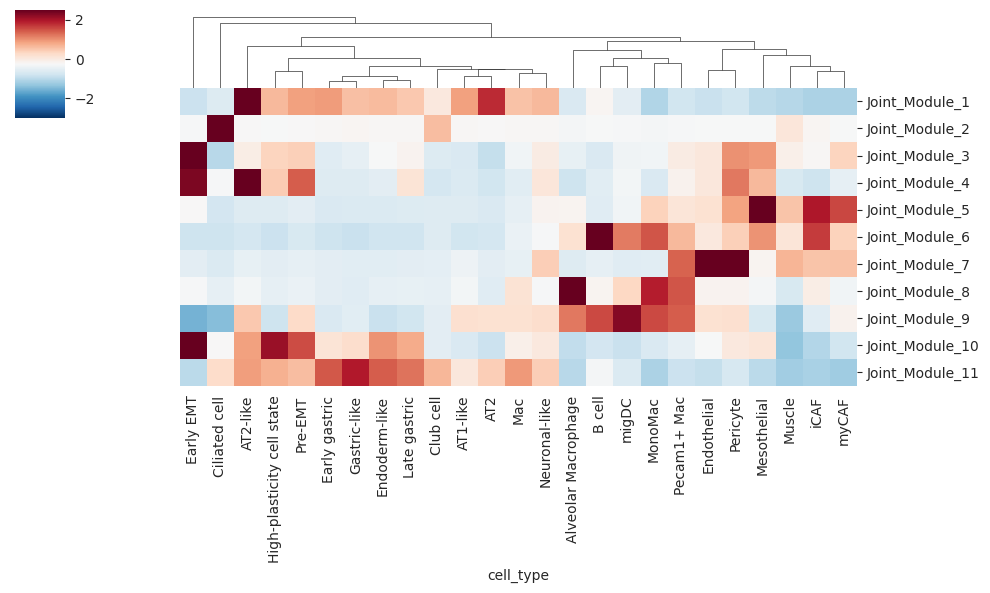

In [45]:
program_names = [f'Joint_Module_{i}' for i in range(1, 12)]
# program_names = [f'Joint_Module_{i}' for i in range(1, len(program_names)+1)]
sns.clustermap(adata_raw.obs.groupby('cell_type').agg({k: 'median' for k in program_names}).T,
               cmap='RdBu_r',
               # cmap=sns.color_palette("blend:#FFFFFF,#febb81,#f8765c,#d3436e,#982d80,#5f187f,#221150",as_cmap=True),
               vmax=2.5,
               vmin=-3,
               col_cluster=True,
               row_cluster=False,
               figsize=(10,6),
               z_score=0,
               # standard_scale=0,
              )
plt.show()

